Primer avance de Proyecto Dinamica colectiva no lineal en una Magneto-Optical
Trap (MOT)  
  
Una trampa opto-magnetica es un confinamiento para atomos neutros. Especialmente para estos atomos ya que el campo magnetico producido para confinar a los atomos no produce una fuerza de Lorenz asociada, pero si modifica las energias internas de los atomos, dando lugar al Efecto Zeemann. La MOT depende de campos magneticos no homogeneos, interaccion radiativa, que permite el enfriamiento de estos ya que reducen su movimiento y de las reglas de seleccion radiativas, es decir, que transiciones estan permitidas y entrega una fuerza restauradora al sistema.  
  
Este mecanismo funciona mediante un bombeo optico, que reorganiza la poblacion de los subniveles internos de los atomos que se mueven lentamente en un campo magnetico. En el caso unidimensional se inyectan dos campos o laseres contrapropagantes con polarizaciones circulares opuestas y con una frecuencia cercana a la de la transicion atomica, que permitiria la transicion de entre algunos estados si las frecuencias estan en resonancia. Ademas, estos laseres contrapropagantes, dependiendo de si el atomo esta mas cerca de uno que de otro, induce una fuerza restauradora que en palabras simples, empuja al atomo al centro del confinamiento. Como se menciono anteriormente el campo magnetico desplaza los estados excitados y, dependiendo de la posicion del atomo en el confinamiento espacial, este percibe de distinta manera la distancia entre niveles por este mismo efecto.   
De esta manera se obtiene de manera simultanea la compresion y enfriamiento del atomo.  
  
El objetivo de esta primera parte del informe sera encontrar numericamente la evolucion del estado excitado del sistema y su operador de subida o bajada variando los parametros del acoplamiento y el detuning. Para ello utilizaremos las ecuaciones opticas de Bloch. Como primer paso es definir el super operador de Linblad:

$\mathcal{L}(\cdot)=-i[H,\cdot] + \sum_{k}\gamma_{k} [L_{k} \cdot L^{\dagger}_{k}-\frac{1}{2}{L^{\dagger}_{k}L_{k},\cdot}] $  
  
Donde $H$ es el hamiltoniano del sistema, $\gamma_{k}$ son las tasas de disipacion del sistema y $L$ los operadores asociados a estas tasas.  

In [8]:
import numpy as np

def Lindblad(t, matrixdensity_flat, H, Loper, rates):
    dim=H.shape[0]
    Mdensity=matrixdensity_flat.reshape((dim, dim))

    #Conmutador
    
    C=-1j * (H@Mdensity-Mdensity@H)

    #Disipacion

    D=np.zeros_like(Mdensity, dtype=complex)
    for L, gamma in zip(Loper, rates):
        Ldagger=L.conj().T
        D+=gamma*(L@Mdensity@Ldagger)
        D-=0.5*gamma*(Ldagger@L@Mdensity+Mdensity@Ldagger@L)

    dmatrixdensity_dt= C+D
    return dmatrixdensity_dt.flatten()


El Hamiltoniano del sistema de dos niveles esta dado por:  
  
$H=-\frac{\delta}{2}\sigma_{z} - (\Omega \sigma_{+} + \Omega^{*}\sigma_{-})$  

Donde $\delta=\omega-\omega_{0}$ es el detuning, $\omega$ es la frecuencia del laser y $\omega_{0}$ es la frecuencia natural de transicion del atomo. Ademas $\Omega$ es la frecuencia de Rabi y $\sigma_{z}, \sigma_{+}, \sigma_{-}$ son los operadores de pauli $z$, de subida y bajada, respectivamente. Considerando $\hbar=1$. 

Es importante destacar que a este hamiltoniano se le aplico una aproximacion dipolar electrica, una aproximacion de onda rotante y fue traslado al cuadro rotante con el fin de obtener un mejor analisis del sistema.  

Se definen ademas, las matrices de pauli y los operadores de subida y bajada que nos seran utiles mas adelante:  

$\sigma_x = \begin{pmatrix} 
0 & 1 \\ 
1 & 0
\end{pmatrix}$  

$\sigma_y = \begin{pmatrix} 
0 & -i \\ 
i & 0
\end{pmatrix}$  

$\sigma_z = \begin{pmatrix} 
1 & 0 \\ 
0 & -1
\end{pmatrix}$  

$\sigma_+ = \begin{pmatrix} 
0 & 1 \\ 
0 & 0
\end{pmatrix}$  

$\sigma_- = \begin{pmatrix} 
0 & 0 \\ 
1 & 0
\end{pmatrix}$  

In [9]:
#Operadores

sigma_x=np.array([[0,1],[1,0]], dtype=complex)
sigma_y=np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z=np.array([[1,0],[0,-1]], dtype=complex)
sigma_plus=np.array([[0,1],[0,0]], dtype=complex)
sigma_minus=np.array([[0,0],[1,0]], dtype=complex)

La ecuacion maestra de Linblad describe la evolucion de la matriz densidad de un sistema abierto, considerando tanto la parte del sistema de interes como su interaccion con el medio. En particular, nos interesa como evolucion la matriz densidad de nuestro sistema de dos niveles. Esta ecuacion es tal que:

$\dot{\rho}=-i[H,\rho_{s}]+\gamma_{0}\left( \sigma_{-}\rho \sigma_{+}-\frac{1}{2}\{\sigma_{+}\sigma_{-}, \rho \}\right)$  

Esta ecuacion representa la evolucion temporal de nuestro sistema a temperatura $K=0 considerando una emision espontanea con el medio (el atomo regala una excitacion). El primer termino corresponde a la dinamica cerrada del sistema y el segundo termino a la disipacion que nace de la interaccion con el medio.  

Podriamos resolver esta ecuacion, pero fisicamente no es tan reveladora. Por lo cual tomamos el enfoque de las ecuaciones de movimiento de Bloch que analiza como evolucionan los valores promedio de los operadores $\sigma_{x}, \sigma_{y}, \sigma_{z}$ que representan la parte real e imaginaria de las coherencias y las poblaciones de estado excitado y el fundamental, respectivamente.  

Para esto, sabemos que el valor promedio de cualquier operador tiene la forma:  

$\langle O \rangle = \text{Tr}(\rho O)$    

Con esto en mente lo que haremos sera integrar la ecuacion de linblad y obtener su forma dependiente del tiempo para luego obtener los valores promedios de los operadores de pauli y de subida y bajada. Tambien nos interesa el elemento matricial de la poblacion excitada.

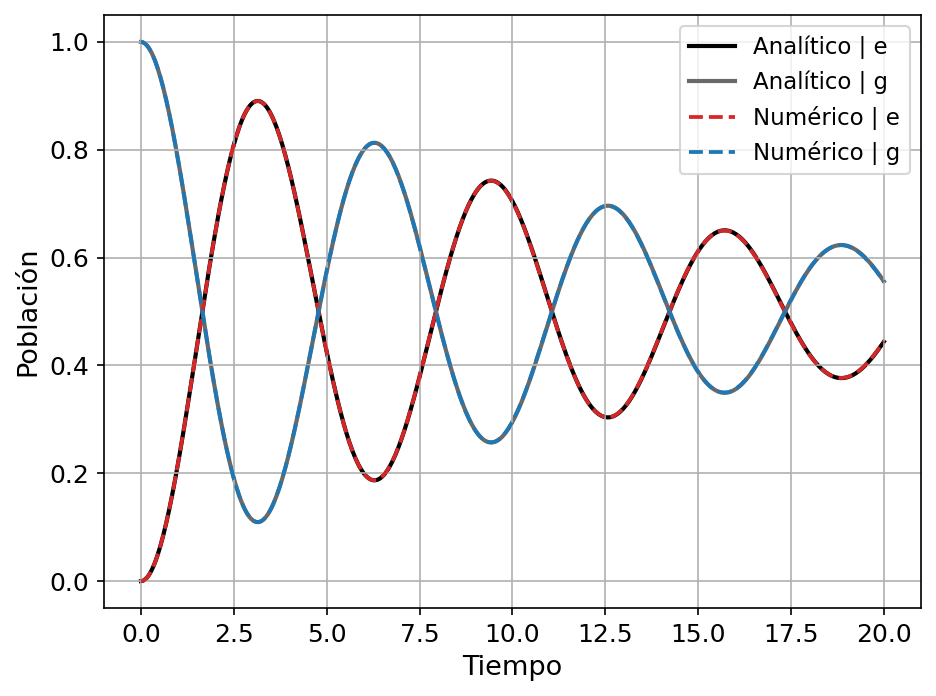

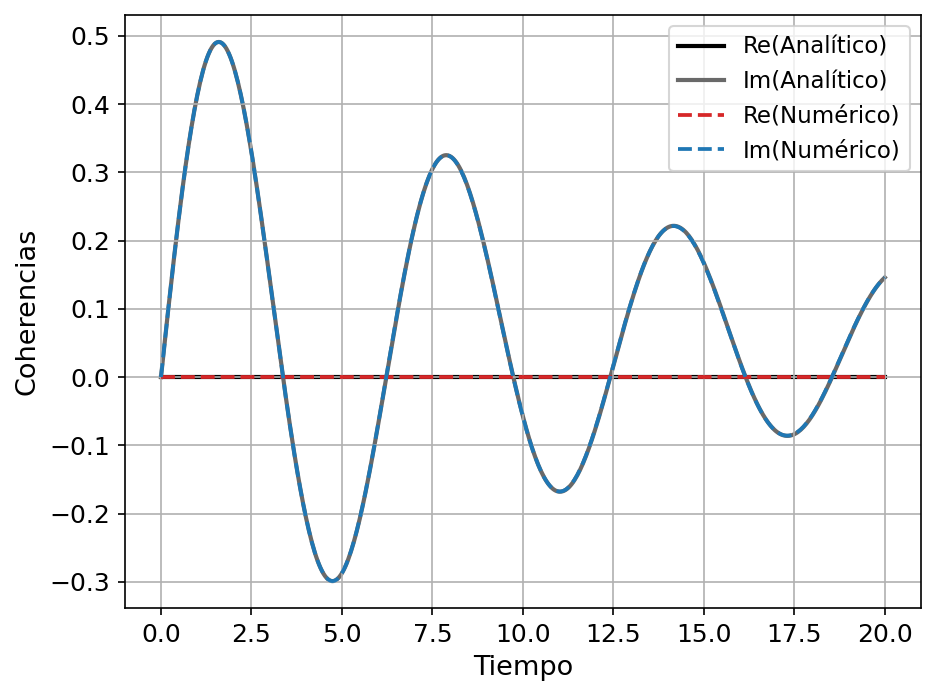

4.440892098500626e-16


In [39]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#Variables

w_0=1          #Frecuencia de transicion del atomo
w=w_0     #Frecuencia del laser
delta=w-w_0    #Detuning
Omega=1        #Frecuencia de Rabi
Gamma=0.1*Omega        #Tasa de decaimiento

#Hamiltoniano (consideramos Rabi real)

H=-(delta/2) * sigma_z - (Omega/2) * sigma_x

#Operadores y tasas para funcion Linblad

Loper=[sigma_minus]
rates=[Gamma]

#Condicion inicial

Mdensity_0=np.array([[0,0],[0,1]], dtype=complex).flatten()     #Dinamica comienza en Estado fundamental

#Solucion

sol= solve_ivp(Lindblad, (0,20), Mdensity_0, t_eval=np.linspace(0,20,500), args=(H, Loper, rates))

#Reconstruimos la matriz densidad y separamos elementos

Mdensity_t = sol.y.T.reshape(-1, 2, 2)
t = sol.t

Mdensity_ee = np.real([Mdensity[0,0] for Mdensity in Mdensity_t])
Mdensity_gg = np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
Mdensity_eg = [Mdensity[0,1] for Mdensity in Mdensity_t]
Mdensity_ge = [Mdensity[1,0] for Mdensity in Mdensity_t]

#Poblacion excitada Analitica si detuning

mu = np.sqrt(Omega**2 - (Gamma/4)**2)

def p_ee(t):
    A = (Omega**2) / (Gamma**2 + 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + (3*Gamma/(4*mu))*np.sin(mu*t))
    )

y = p_ee(t)

def p_eg(t):
    A = ( 1j*Omega*Gamma ) / ( Gamma**2+ 2*Omega**2)
    
    return A * (
        1 - np.exp(-3*Gamma*t/4) *
        (np.cos(mu*t) + ((Gamma/(4*mu))-(Omega**2/(mu*Gamma)))*np.sin(mu*t))
    )

z = p_eg(t)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

# =========================
# PLOT POBLACIONES
# =========================
plt.figure()

# analítico (referencia)
plt.plot(t, y, label="Analítico | e", linewidth=2, color='black', zorder=1)
plt.plot(t, 1 - y, label="Analítico | g", linewidth=2, color='dimgray', zorder=1)

# numérico (comparación)
plt.plot(t, Mdensity_ee, '--', label="Numérico | e", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_gg, '--', label="Numérico | g", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# PLOT COHERENCIAS
# =========================
Mdensity_eg_real = np.real(Mdensity_eg)
Mdensity_eg_imag = np.imag(Mdensity_eg)

plt.figure()

# analítico
plt.plot(t, np.real(z), label="Re(Analítico)", linewidth=2, color='black', zorder=1)
plt.plot(t, np.imag(z), label="Im(Analítico)", linewidth=2, color='dimgray', zorder=1)

# numérico
plt.plot(t, Mdensity_eg_real, '--', label="Re(Numérico)", linewidth=1.8, color='tab:red', zorder=2)
plt.plot(t, Mdensity_eg_imag, '--', label="Im(Numérico)", linewidth=1.8, color='tab:blue', zorder=2)

plt.xlabel("Tiempo")
plt.ylabel("Coherencias")
plt.legend()
plt.tight_layout()
plt.show()

#Verificando traza

print(np.max(np.abs(Mdensity_ee + Mdensity_gg - 1)))